In [1]:
%autoreload 2

In [2]:
import json
from pathlib import Path
import os

import torch
import numpy as np
from datasets import load_dataset
from huggingface_hub import snapshot_download, login, whoami

In [3]:
# login to hf
hf_token = Path.home().joinpath(".cache/huggingface/token").read_text().strip()
login(token=hf_token)

print(f"logged in as {whoami()['name']}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


logged in as eturok


## Add mask area to dataset

In [6]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train', token=hf_token)
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz", token=hf_token)

Resolving data files:   0%|          | 0/450 [00:00<?, ?it/s]

Fetching 450 files:   0%|          | 0/450 [00:00<?, ?it/s]

In [7]:
idx = 3
data = np.load(os.path.join(snapshot_dir, sample_npz_path(ds[idx]['sample_idx'])))
mask = torch.from_numpy(data['mask'].astype(np.float32))

In [8]:
mask.sum() / mask.numel() * 100

tensor(1.5216)

In [9]:
def compute_mask_area(sample: dict) -> dict:
    """Compute the percentage of mask pixels that are 1 (foreground)."""
    data = np.load(os.path.join(snapshot_dir, sample_npz_path(sample['sample_idx'])))
    mask = data['mask'].astype(np.float32)
    return {"mask_area": float(mask.sum() / mask.size * 100)}

ds = ds.map(compute_mask_area)
ds.push_to_hub("eturok-weizmann/vibrations", split="train", token=hf_token)

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/eturok-weizmann/vibrations/commit/006c1ff99b7b885b0dec75c07ac83a7c6618a47a', commit_message='Upload dataset', commit_description='', oid='006c1ff99b7b885b0dec75c07ac83a7c6618a47a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/eturok-weizmann/vibrations', endpoint='https://huggingface.co', repo_type='dataset', repo_id='eturok-weizmann/vibrations'), pr_revision=None, pr_num=None)

## Delete local directory for experiments already in hf

We did not save the path of the sample in the local-dir and shared-dir to hf. So to map the hf sample to the sample in local-dir we compare the experiment configs in both.

In [ ]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train', columns=["experiment_config"], download_mode='force_redownload', verification_mode='no_checks')

In [5]:
def find_experiment_dir(config: dict, path: str | Path) -> Path | None:
    """Return the top-level subdirectory of `path` whose experiment_config.json contains all key-value pairs in `config`."""
    for subdir in Path(path).iterdir():
        cfg_file = subdir / "experiment_config.json"
        if not subdir.is_dir() or not cfg_file.exists():
            continue
        with open(cfg_file) as f:
            saved = json.load(f)
        if all(saved.get(k) == v for k, v in config.items()):
            return subdir
    return None

In [6]:
ds

Dataset({
    features: ['experiment_config'],
    num_rows: 450
})

In [12]:
idx = -1
exp_config = json.loads(ds[idx]["experiment_config"])
exp_config

{'ROI_ROW_HEIGHT': 30,
 'N_ROI_ROWS': 10,
 'N_ROI_COLUMNS': 10,
 'ROI_COLUMN_WIDTH': 70,
 'CALIBRATION_FPS': 500,
 'CALIBRATION_EXPOSURE': 30,
 'CALIBRATION_GAIN': 3,
 'FPS': 2500,
 'EXPOSURE': 150,
 'GAIN': 1,
 'BUFFER_PART_COUNT': 3000,
 'EXPOSURE_MS': 30,
 'FRAME_RATE': 30,
 'PIXEL_CLOCK': 86,
 'CAMERA_GAIN': 60,
 'RESIZE_FACTOR': 0.75,
 'GAMMA': 1.0,
 'AUDIO_FILE': '..\\data\\audio_samples\\chirp_50_1000_3.0sec.wav',
 'N_CAPTURE_SECONDS': 3.1,
 'speakers': [0, 1, 0, 0],
 'object': 'cube',
 'n_objects': 1,
 'box_material': 'cardboard'}

In [22]:
import shutil

for idx, row in enumerate(ds):
    exp_config = json.loads(row["experiment_config"])
    sample_dir = find_experiment_dir(exp_config, r"C:\Users\eitanturok\experiments\experiment-15")
    print(f'{idx=}, {sample_dir=}')
    try:
        shutil.rmtree(sample_dir)
        print('deleted')
    except Exception as e:
        print(e)

idx=0, sample_dir=None
lstat: path should be string, bytes or os.PathLike, not NoneType
idx=1, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/empty_1000--31-03-18-14-12')
deleted
idx=2, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0001--31-03-18-21-24')
deleted
idx=3, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0010--31-03-18-21-22')
deleted
idx=4, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0100--31-03-18-21-20')
deleted
idx=5, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_1000--31-03-18-21-18')
deleted
idx=6, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x02y_0001--31-03-18-27-14')
deleted
idx=7, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x02y_0010--31-03-18-27-11')
deleted
idx=8, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/c

## Inspect shifts

In [ ]:
data = np.load(os.path.join(snapshot_dir, sample_npz_path(ds[idx]['sample_idx'])))
shifts, mask = torch.from_numpy(data['shifts']), torch.from_numpy(data['mask'].astype(np.float32))

In [20]:
shifts.shape

torch.Size([100, 9000, 2])

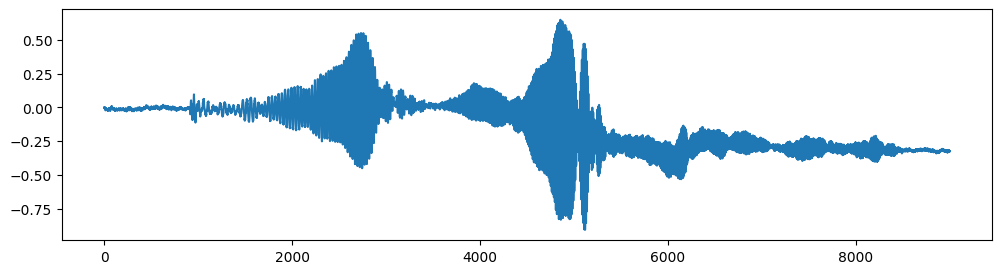

In [22]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(shifts[50, :, 1])
plt.show()

## Inspect Mask Areas

In [10]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train')
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz")

README.md:   0%|          | 0.00/747 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/450 [00:00<?, ? examples/s]

Fetching 450 files:   0%|          | 0/450 [00:00<?, ?it/s]

/var/folders/f6/vzqh7ynx4n3ft_sx36yv3gbm0000gn/T/ipykernel_57459/1149639245.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  is_outlier = np.abs(stats.zscore(vals)) > 2.5


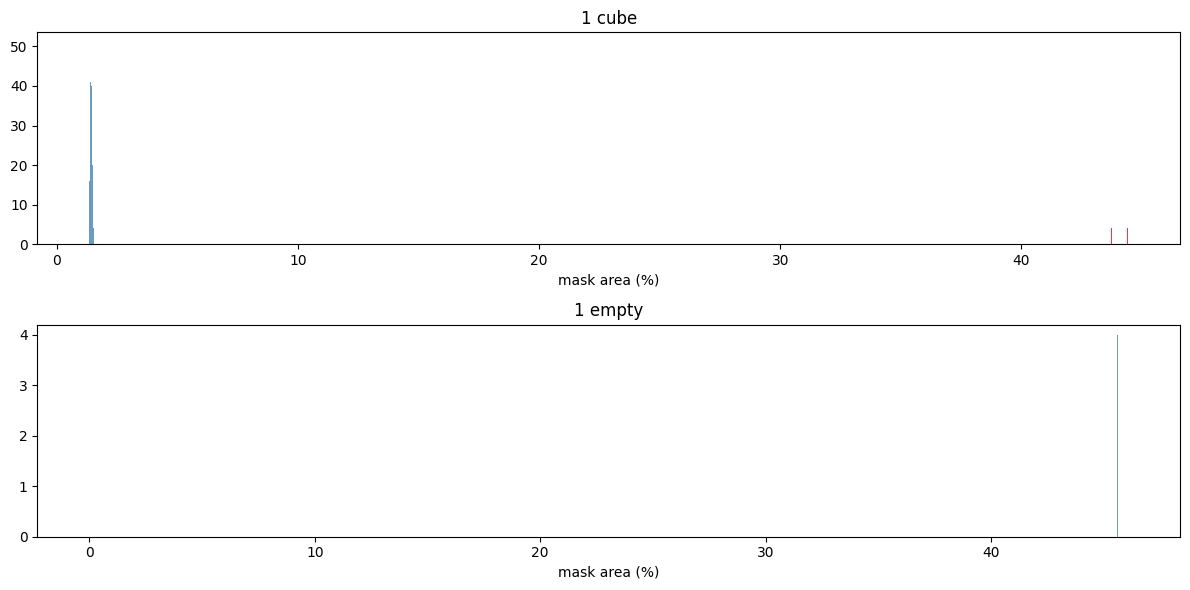

{('cube', 1): [52, 53, 54, 55, 60, 61, 62, 63], ('empty', 1): []}

In [ ]:
import pandas as pd
from scipy import stats
from PIL import Image
import matplotlib.pyplot as plt

df = pd.DataFrame({'object': ds['object'], 'n_objects': ds['n_objects'],
                   'mask_area': ds['mask_area'], 'sample_idx': ds['sample_idx'],
                   'hf_idx': range(len(ds))})

def pluralize(word: str, count: int) -> str: return word if count == 1 else word + 's'

# --- histograms ---
groups = df.groupby(['n_objects', 'object'])
n_groups = len(groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(12, 3 * n_groups))
outliers = {}
for ax, ((n_obj, obj), grp) in zip(np.array(axes).flatten(), groups):
    vals = grp['mask_area'].values
    is_outlier = np.abs(stats.zscore(vals)) > 2.5
    ax.hist(vals[~is_outlier], bins=20, color='steelblue', alpha=0.8)
    ax.hist(vals[ints_outlier], bins=20, color='red', alpha=0.8)
    ax.set_title(f'{n_obj} {pluralize(obj, n_obj)}')
    ax.set_xlabel('mask area (%)')
    outliers[(obj, n_obj)] = grp.loc[is_outlier, 'hf_idx'].tolist()
plt.tight_layout()
plt.show()

outliers

[1 cube]
hf_idx=52  sample_idx=52  area=43.7%  mean=2.2%  deviation=+41.5%


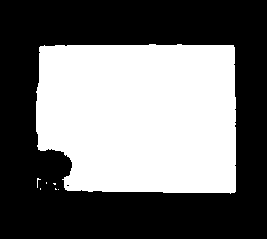

[1 cube]
hf_idx=53  sample_idx=53  area=43.7%  mean=2.2%  deviation=+41.5%


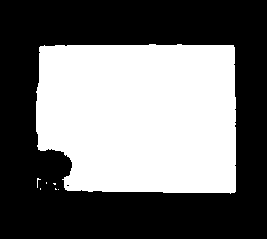

[1 cube]
hf_idx=54  sample_idx=54  area=43.7%  mean=2.2%  deviation=+41.5%


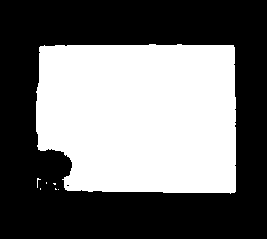

[1 cube]
hf_idx=55  sample_idx=55  area=43.7%  mean=2.2%  deviation=+41.5%


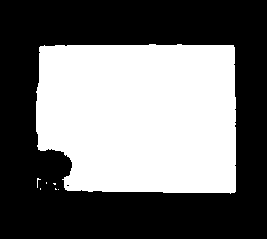

[1 cube]
hf_idx=60  sample_idx=60  area=44.4%  mean=2.2%  deviation=+42.2%


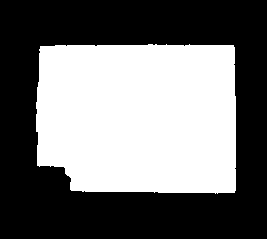

[1 cube]
hf_idx=61  sample_idx=61  area=44.4%  mean=2.2%  deviation=+42.2%


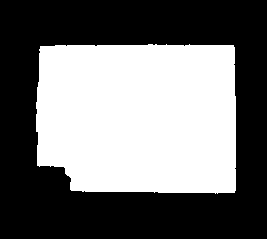

[1 cube]
hf_idx=62  sample_idx=62  area=44.4%  mean=2.2%  deviation=+42.2%


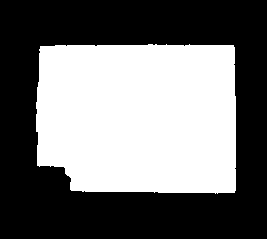

[1 cube]
hf_idx=63  sample_idx=63  area=44.4%  mean=2.2%  deviation=+42.2%


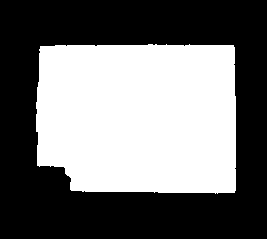

In [55]:
# --- print outlier indices and show their masks ---
for (obj, n_obj), hf_indices in outliers.items():
    grp = df[(df['object'] == obj) & (df['n_objects'] == n_obj)]
    mean_area = grp['mask_area'].mean()
    label = f"{n_obj} {pluralize(obj, n_obj)}"
    for hf_idx in hf_indices:
        row = df[df['hf_idx'] == hf_idx].iloc[0]
        mask = np.load(os.path.join(snapshot_dir, sample_npz_path(row['sample_idx'])))['mask']
        print(
            f"[{label}]\n"
            f"hf_idx={int(row['hf_idx'])}  sample_idx={int(row['sample_idx'])}  "
            f"area={row['mask_area']:.1f}%  mean={mean_area:.1f}%  "
            f"deviation={row['mask_area'] - mean_area:+.1f}%"
        )
        img = Image.fromarray((mask * 255).astype(np.uint8))
        w, h = img.size
        display(img.resize((w // 4, h // 4), Image.NEAREST))

## Rerun Segmentation

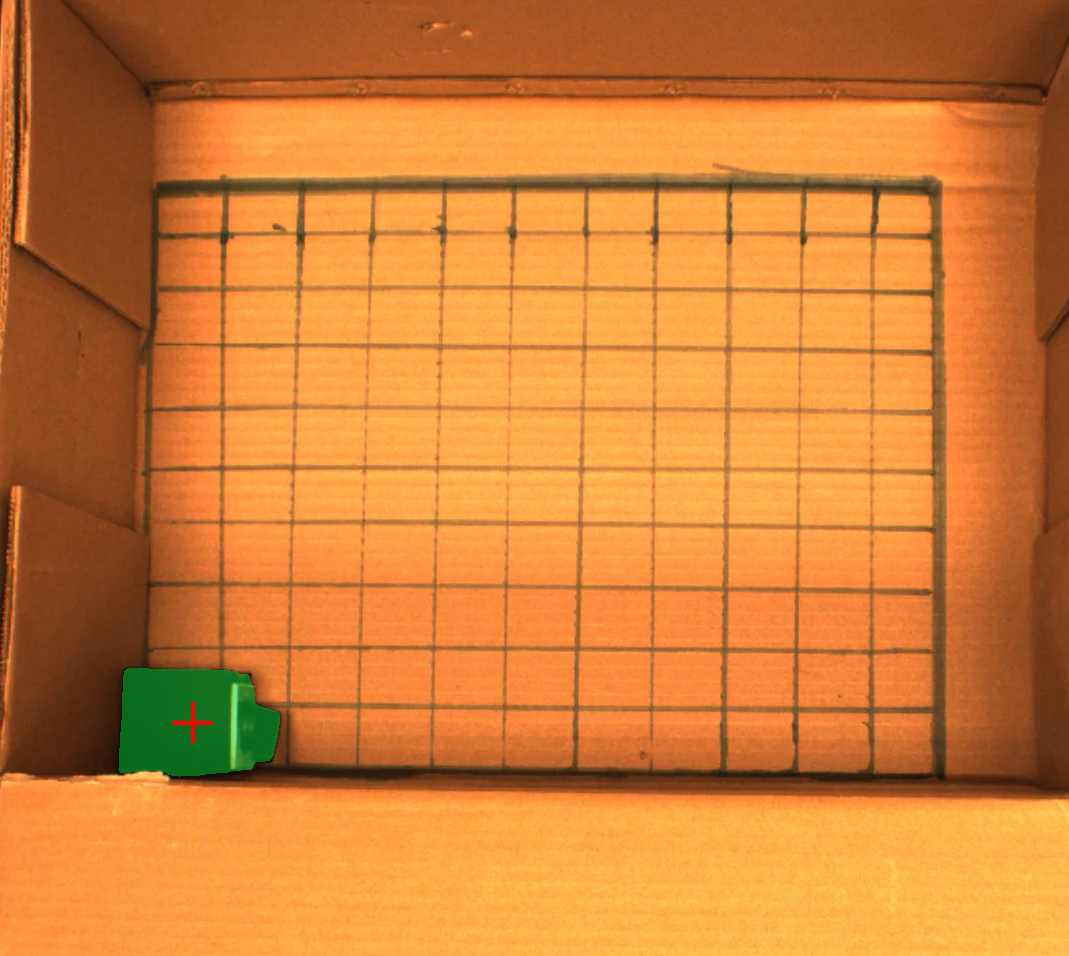

x_position: 192.84, y_position: 722.24


In [56]:
import sys
sys.path.insert(0, "..")
from utils.segment import segment_sample, PROMPT
from PIL import Image as PILImage

hf_idx = 60
row = ds[hf_idx]
exp_config = json.loads(row["experiment_config"])

raw_image = PILImage.fromarray(np.array(row["raw_image"].convert("RGB"), dtype=np.uint8))
prompt = PROMPT

mask, vision = segment_sample(
    raw_image=raw_image,
    left=0.15,
    right=0.67,
    up=0.08,
    down=0.7,
    object=exp_config["object"],
    box_material=exp_config["box_material"],
    prompt=prompt,
)

display(vision["overlay_image"])
print(f"x_position: {vision['x_position']:.2f}, y_position: {vision['y_position']:.2f}")

In [60]:
import io
import sys
sys.path.insert(0, "..")
from utils.segment import segment_sample
from huggingface_hub import HfApi

all_outlier_indices = set(hf_idx for hf_indices in outliers.values() for hf_idx in hf_indices)

def resegment_sample(sample: dict, idx: int) -> dict:
    if idx not in all_outlier_indices:
        return {}
    exp_config = json.loads(sample["experiment_config"])
    raw_image = Image.fromarray(np.array(sample["raw_image"].convert("RGB"), dtype=np.uint8))
    mask, vision = segment_sample(
        raw_image=raw_image,
        object=exp_config["object"],
        box_material=exp_config["box_material"],
    )
    mask_arr = np.array(mask, dtype=np.float32)

    # load existing npz, replace mask, re-upload
    npz_path = os.path.join(snapshot_dir, sample_npz_path(sample['sample_idx']))
    existing = np.load(npz_path)
    buf = io.BytesIO()
    np.savez_compressed(buf, shifts=existing['shifts'], mask=mask_arr)
    buf.seek(0)
    HfApi().upload_file(
        path_or_fileobj=buf,
        path_in_repo=sample_npz_path(sample['sample_idx']),
        repo_id=repo_id,
        repo_type="dataset",
        token=hf_token,
    )

    return {
        "mask_area":     float(mask_arr.sum() / mask_arr.size * 100),
        "x_position":    vision["x_position"],
        "y_position":    vision["y_position"],
        "overlay_image": vision["overlay_image"],
    }

ds = ds.map(resegment_sample, with_indices=True)
ds.push_to_hub(repo_id, split="train", token=hf_token)

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/eturok-weizmann/vibrations/commit/38bb48bec87c6261710a3c9e2bfb4e5714fb3c7e', commit_message='Upload dataset', commit_description='', oid='38bb48bec87c6261710a3c9e2bfb4e5714fb3c7e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/eturok-weizmann/vibrations', endpoint='https://huggingface.co', repo_type='dataset', repo_id='eturok-weizmann/vibrations'), pr_revision=None, pr_num=None)

# Fix Empty Mask

In [7]:
import io
from huggingface_hub import HfApi
from PIL import Image

repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train', token=hf_token)
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz", token=hf_token)

empty_indices = [i for i, obj in enumerate(ds['object']) if obj == 'empty']
print(f"Found {len(empty_indices)} samples with object='empty': {empty_indices}")

def zero_mask(sample: dict, idx: int) -> dict:
    if idx not in empty_indices:
        return {}
    npz_path = os.path.join(snapshot_dir, sample_npz_path(sample['sample_idx']))
    existing = np.load(npz_path)
    mask_arr = np.zeros_like(existing['mask'], dtype=bool)

    buf = io.BytesIO()
    np.savez_compressed(buf, shifts=existing['shifts'], mask=mask_arr)
    buf.seek(0)
    HfApi().upload_file(
        path_or_fileobj=buf,
        path_in_repo=sample_npz_path(sample['sample_idx']),
        repo_id=repo_id,
        repo_type="dataset",
        token=hf_token,
    )
    return {"mask_area": 0.0, "x_position": -1.0, "y_position": -1.0, "overlay_image": sample["cropped_image"]}

ds = ds.map(zero_mask, with_indices=True)
ds.push_to_hub(repo_id, split="train", token=hf_token)
print("Done.")

README.md:   0%|          | 0.00/747 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/222M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/450 [00:00<?, ? examples/s]

Fetching 450 files:   0%|          | 0/450 [00:00<?, ?it/s]

Found 4 samples with object='empty': [0, 1, 10, 11]


...

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Done.


# Inspect sample

In [6]:
repo_id = 'eturok-weizmann/vibrations'
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns=sample_npz_path(1), token=hf_token)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
data = np.load(os.path.join(snapshot_dir, sample_npz_path(1)))
mask = torch.from_numpy(data['mask'].astype(np.float32))
shifts = torch.from_numpy(data['shifts'].astype(np.float32))

In [8]:
shifts.shape

torch.Size([100, 9000, 2])

In [9]:
mask.shape

torch.Size([956, 1069])

In [10]:
ds = load_dataset(repo_id, split='train', token=hf_token, columns=["sample_idx", "x_position", "y_position", "object", "fps", "speakers", 'experiment_config'])

Resolving data files:   0%|          | 0/98 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/98 [00:00<?, ?it/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

data/train-00450.parquet:   0%|          | 0.00/467k [00:00<?, ?B/s]

data/train-00451.parquet:   0%|          | 0.00/467k [00:00<?, ?B/s]

...

data/train-00544.parquet:   0%|          | 0.00/467k [00:00<?, ?B/s]

data/train-00545.parquet:   0%|          | 0.00/467k [00:00<?, ?B/s]

data/train-00546.parquet:   0%|          | 0.00/467k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/450 [00:00<?, ? examples/s]

NonMatchingSplitsSizesError: [{'expected': SplitInfo(name='train', num_bytes=210901623, num_examples=450, shard_lengths=None, original_shard_lengths=None, dataset_name=None), 'recorded': SplitInfo(name='train', num_bytes=330241, num_examples=547, shard_lengths=None, original_shard_lengths=None, dataset_name='vibrations')}]

In [ ]:
ex = ds[1]
ex

# Fix n_objects

* 471-482 has 4 objects
* 483-490 has 5 objects
* 515-522 has 2 objects
* 523-527 has 1 object
* 527-546 has 2 objects

In [6]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train', token=hf_token, download_mode='force_redownload', verification_mode='no_checks')
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz", token=hf_token)

# (n_objects, inclusive sample_idx range)
n_objects_fixes = [
    (4, range(471, 483)),   # 471-482
    (5, range(483, 491)),   # 483-490
    (2, range(515, 523)),   # 515-522
    (1, range(523, 527)),   # 523-526
    (2, range(527, 547)),   # 527-546
]
sample_idx_to_n_objects = {idx: n_obj for n_obj, rng in n_objects_fixes for idx in rng}

def fix_n_objects(sample: dict) -> dict:
    sample_idx = sample['sample_idx']
    if sample_idx not in sample_idx_to_n_objects:
        return {}
    n_obj = sample_idx_to_n_objects[sample_idx]
    exp_config = json.loads(sample['experiment_config'])
    exp_config['n_objects'] = n_obj
    return {'n_objects': n_obj, 'experiment_config': json.dumps(exp_config)}

ds = ds.map(fix_n_objects)
ds.push_to_hub(repo_id, split='train', token=hf_token)
print("Done.")

README.md:   0%|          | 0.00/747 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/255M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/547 [00:00<?, ? examples/s]

Fetching 547 files:   0%|          | 0/547 [00:00<?, ?it/s]

Map:   0%|          | 0/547 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/547 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Done.


# Fix layouts

* 454, 459-470 layout is off-grid, rotated along z axis (facing the other way), past border of box grid
* 471-474 layout is vertical line, 4 cubes side by side touching + next to each other
* 475-478 layout is diagonal line, 4 cubes side by side touching + next to each other
* 479-482 layout is horiztonal line, 4 cubes touching side by side next to each other
* 483-490, layout is L-shaped, 5 cubes toucnning side by side
* 491-494 layout is off-grid
* 495-498 layout is off-grid, rotated along z axis (facing the other way), past border of box grid
* 499-502 layout is off-grid, rotated along y axis (knob faces upward)
* 503-506 layout is off-grid, rotated along y axis (knob faces upward), past border of box grid
* 507-510 layout is off-grid, rotated along y axis (knob faces upward)
* 511-514 layout is off-grid
* 515-522 2 cubes not touching / next to each other
* 523-526 2 cubes stacked on top of each other
* 527-534 2 cubes touching / next to each other
* 535-542 2 cubes toucjing / next to each other, rotated along y axis (knob faces other way)
* 543-546 2 cubes touching but staggered so not completly touching each other 

* off-grid, rotated (z-axis, knob faces other way), beyond grid boundary
* vertical line, cubes fully touching
* diagonal line, cubes fully touching
* horizontal line, cubes fully touching
* L-shape line, cubes fully touching
* off-grid
* off-grid, rotated (z-axis, knob faces other way), beyond grid boundary
* 

In [ ]:
repo_id = 'eturok-weizmann/vibrations'
ds_train = load_dataset(repo_id, split='train', token=hf_token, download_mode='force_redownload', verification_mode='no_checks')

# sample_idx -> tags (comma-separated string)
layout_map = {
    **{idx: ('out-of-grid placement, (z-axis, knob faces down), beyond grid boundary', 'off_grid,z_rotation')
       for idx in [454, *range(459, 471)]},       # 454, 459-470
    **{idx: ('4 objects in a vertical line, side-by-side touching', 'vertical_line,touching')
       for idx in range(471, 475)},                # 471-474
    **{idx: ('4 objects in a diagonal line, side-by-side touching', 'diagonal_line,touching')
       for idx in range(475, 479)},                # 475-478
    **{idx: ('4 objects in a horizontal line, side-by-side touching', 'horizontal_line,touching')
       for idx in range(479, 483)},                # 479-482
    **{idx: ('5 objects in an L-shape, side-by-side touching', 'l_shape,touching')
       for idx in range(483, 491)},                # 483-490
    **{idx: ('out-of-grid placement', 'off_grid')
       for idx in range(491, 495)},                # 491-494
    **{idx: ('out-of-grid placement, (z-axis, knob faces down), beyond grid boundary', 'off_grid,z_rotation')
       for idx in range(495, 499)},                # 495-498
    **{idx: ('out-of-grid placement, (y-axis, knob faces upward)', 'off_grid,y_rotation')
       for idx in range(499, 503)},                # 499-502
    **{idx: ('out-of-grid placement, (y-axis, knob faces upward), beyond grid boundary', 'off_grid,y_rotation')
       for idx in range(503, 507)},                # 503-506
    **{idx: ('out-of-grid placement, (y-axis, knob faces upward)', 'off_grid,y_rotation')
       for idx in range(507, 511)},                # 507-510
    **{idx: ('out-of-grid placement', 'off_grid')
       for idx in range(511, 515)},                # 511-514
    **{idx: ('2 objects separated, not touching', 'separated')
       for idx in range(515, 523)},                # 515-522
    **{idx: ('2 objects stacked vertically', 'stacked')
       for idx in range(523, 527)},                # 523-526
    **{idx: ('2 objects side-by-side touching', 'touching')
       for idx in range(527, 535)},                # 527-534
    **{idx: ('2 objects side-by-side touching, (y-axis, knob faces away)', 'touching,y_rotation')
       for idx in range(535, 543)},                # 535-542
    **{idx: ('2 objects staggered, partially touching', 'staggered,touching')
       for idx in range(543, 547)},                # 543-546
}
ood_sample_indices = set(layout_map.keys())

def add_layout_description(sample: dict) -> dict:
    entry = layout_map.get(sample['sample_idx'])
    return {'layout_description': entry[1] if entry else None}

ds_train = ds_train.map(add_layout_description)

ood_mask = [s in ood_sample_indices for s in ds_train['sample_idx']]
ds_ood   = ds_train.filter(lambda _, i: ood_mask[i], with_indices=True)
ds_train = ds_train.filter(lambda _, i: not ood_mask[i], with_indices=True)

print(f'train: {len(ds_train)} samples, ood: {len(ds_ood)} samples')

ds_train.push_to_hub(repo_id, split='train', token=hf_token)
ds_ood.push_to_hub(repo_id, split='ood', token=hf_token)
print('Done.')

## Rename HF Sample Files

In [6]:
from collections import Counter
import re
from huggingface_hub import HfApi, CommitOperationCopy, CommitOperationDelete

import sys
sys.path.insert(0, "..")
from src.helpers import sample_npz_path

W0419 10:42:10.268000 39490 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [7]:
repo_id = 'eturok-weizmann/vibrations'
api = HfApi(token=hf_token)
repo_files = list(api.list_repo_files(repo_id, repo_type='dataset'))
sample_files = sorted(f for f in repo_files if f.startswith('data/sample_') and f.endswith('.npz'))

def extract_sample_idx(path: str) -> int:
    match = re.fullmatch(r'data/sample_(\d+)\.npz', path)
    if match is None:
        raise ValueError(f'Unexpected sample path: {path}')
    return int(match.group(1))

rename_plan = []
for old_path in sample_files:
    sample_idx = extract_sample_idx(old_path)
    new_path = sample_npz_path(sample_idx)
    if old_path != new_path:
        rename_plan.append((old_path, new_path))

duplicate_targets = [path for path, count in Counter(new for _, new in rename_plan).items() if count > 1]
existing_targets = [new for _, new in rename_plan if new in sample_files]
if duplicate_targets:
    raise RuntimeError(f'Duplicate padded targets detected: {duplicate_targets}')
if existing_targets:
    raise RuntimeError(f'Target paths already exist, refusing to continue: {existing_targets[:10]}')

print(f'Found {len(sample_files)} sample npz files; {len(rename_plan)} need renaming.')
for old_path, new_path in rename_plan[:10]:
    print(f'{old_path} -> {new_path}')
if len(rename_plan) > 10:
    print(f'... and {len(rename_plan) - 10} more')

Found 547 sample npz files; 547 need renaming.
data/sample_0.npz -> data/sample_000000.npz
data/sample_1.npz -> data/sample_000001.npz
data/sample_10.npz -> data/sample_000010.npz
data/sample_100.npz -> data/sample_000100.npz
data/sample_101.npz -> data/sample_000101.npz
data/sample_102.npz -> data/sample_000102.npz
data/sample_103.npz -> data/sample_000103.npz
data/sample_104.npz -> data/sample_000104.npz
data/sample_105.npz -> data/sample_000105.npz
data/sample_106.npz -> data/sample_000106.npz
... and 537 more


In [ ]:
RUN_RENAME = False  # set to True to execute the rename plan
if RUN_RENAME and rename_plan:
    copy_commit = api.create_commit(
        repo_id=repo_id,
        repo_type='dataset',
        operations=[
            CommitOperationCopy(src_path_in_repo=old_path, path_in_repo=new_path)
            for old_path, new_path in rename_plan
        ],
        commit_message='Copy sample npz files to 6-digit zero-padded names',
    )
    print(copy_commit.commit_url)

    repo_files_after_copy = set(api.list_repo_files(repo_id, repo_type='dataset'))
    missing_targets = [new_path for _, new_path in rename_plan if new_path not in repo_files_after_copy]
    if missing_targets:
        raise RuntimeError(f'Missing copied targets, not deleting old files: {missing_targets[:10]}')

    delete_commit = api.create_commit(
        repo_id=repo_id,
        repo_type='dataset',
        operations=[CommitOperationDelete(path_in_repo=old_path) for old_path, _ in rename_plan],
        commit_message='Delete legacy unpadded sample npz filenames',
    )
    print(delete_commit.commit_url)
else:
    print('Dry run only. Review the rename plan, then set RUN_RENAME = True to execute.')

https://huggingface.co/datasets/eturok-weizmann/vibrations/commit/0554c44793db5984f4a6b23d38b1334a223bb511
https://huggingface.co/datasets/eturok-weizmann/vibrations/commit/611f24cbde14e1997deecf0500ff7de52c78fddb
